<a href="https://colab.research.google.com/github/sherjahong1r/Machine-Learning-Lessons/blob/main/03_ML_hierarchical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Imgur](https://i.imgur.com/5pXzCIu.png)

# Data Science va Sun'iy Intellekt Praktikum

## 5-MODUL. Machine Learning.

# Clustering

## Ierarxik (hierarchical) algoritm

In [8]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

### Dataset
Ushbu darsda avtomobillarni klasterlaymiz.

In [9]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/cars_clus.csv"
df = pd.read_csv(url)
df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.000,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2.828,0.0
1,Acura,TL,39.384,19.875,0.000,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,3.673,0.0
2,Acura,CL,14.114,18.225,0.000,$null$,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2.647,0.0
3,Acura,RL,8.588,29.725,0.000,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2.150,0.0
4,Audi,A4,20.397,22.255,0.000,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,3.015,0.0


In [10]:
df.shape

(159, 16)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   manufact   157 non-null    object 
 1   model      159 non-null    object 
 2   sales      159 non-null    object 
 3   resale     159 non-null    object 
 4   type       159 non-null    object 
 5   price      159 non-null    object 
 6   engine_s   159 non-null    object 
 7   horsepow   159 non-null    object 
 8   wheelbas   159 non-null    object 
 9   width      159 non-null    object 
 10  length     159 non-null    object 
 11  curb_wgt   159 non-null    object 
 12  fuel_cap   159 non-null    object 
 13  mpg        159 non-null    object 
 14  lnsales    159 non-null    object 
 15  partition  159 non-null    float64
dtypes: float64(1), object(15)
memory usage: 20.0+ KB


In [12]:
# df dagi mavjud bo'lmagan qiymatlar soni
print(f"mavjud bo'lmagan qiymatlar soni: {df.isnull().sum().sum()}")

# mavjud bo'lmagan qatorlar soni
missing_rovs = df[df.isnull().any(axis=1)].shape[0]
print(f"Mavjud bo'lmagan qatorlar soni: {missing_rovs}")

# qatorlar nisbati
print(f"Mavjud bo'lmagan qatorlar %: {np.round(missing_rovs/len(df)*100)}%")

mavjud bo'lmagan qiymatlar soni: 2
Mavjud bo'lmagan qatorlar soni: 2
Mavjud bo'lmagan qatorlar %: 1.0%


Datasetni tozalaymiz.

In [13]:
df[[ 'sales', 'resale', 'type', 'price', 'engine_s',
       'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap',
       'mpg', 'lnsales']] = df[['sales', 'resale', 'type', 'price', 'engine_s',
       'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap',
       'mpg', 'lnsales']].apply(pd.to_numeric, errors='coerce')
df = df.dropna()
df = df.reset_index(drop=True)
df.head(5)

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.0,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2.828,0.0
1,Acura,TL,39.384,19.875,0.0,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,3.673,0.0
2,Acura,RL,8.588,29.725,0.0,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2.150,0.0
3,Audi,A4,20.397,22.255,0.0,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,3.015,0.0
4,Audi,A6,18.780,23.555,0.0,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,2.933,0.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   manufact   117 non-null    object 
 1   model      117 non-null    object 
 2   sales      117 non-null    float64
 3   resale     117 non-null    float64
 4   type       117 non-null    float64
 5   price      117 non-null    float64
 6   engine_s   117 non-null    float64
 7   horsepow   117 non-null    float64
 8   wheelbas   117 non-null    float64
 9   width      117 non-null    float64
 10  length     117 non-null    float64
 11  curb_wgt   117 non-null    float64
 12  fuel_cap   117 non-null    float64
 13  mpg        117 non-null    float64
 14  lnsales    117 non-null    float64
 15  partition  117 non-null    float64
dtypes: float64(14), object(2)
memory usage: 14.8+ KB


In [15]:
# df dagi mavjud bo'lmagan qiymatlar soni
print(f"mavjud bo'lmagan qiymatlar soni: {df.isnull().sum().sum()}")

# mavjud bo'lmagan qatorlar soni
missing_rovs = df[df.isnull().any(axis=1)].shape[0]
print(f"Mavjud bo'lmagan qatorlar soni: {missing_rovs}")

# qatorlar nisbati
print(f"Mavjud bo'lmagan qatorlar %: {np.round(missing_rovs/len(df)*100)}%")

mavjud bo'lmagan qiymatlar soni: 0
Mavjud bo'lmagan qatorlar soni: 0
Mavjud bo'lmagan qatorlar %: 0.0%


In [17]:
df.shape

(117, 16)

Klasterlash uchun ustunlarni tanlab olamiz.

In [18]:
featureset = df[['engine_s',  'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap', 'mpg']]

**Normalizasiya**

In [19]:
from sklearn.preprocessing import MinMaxScaler
x = featureset.values #numpy array
min_max_scaler = MinMaxScaler()
feature_mtx = min_max_scaler.fit_transform(x)
feature_mtx[0:5]

array([[0.11428571, 0.21518987, 0.18655098, 0.28143713, 0.30625832,
        0.2310559 , 0.13364055, 0.43333333],
       [0.31428571, 0.43037975, 0.3362256 , 0.46107784, 0.5792277 ,
        0.50372671, 0.31797235, 0.33333333],
       [0.35714286, 0.39240506, 0.47722343, 0.52694611, 0.62849534,
        0.60714286, 0.35483871, 0.23333333],
       [0.11428571, 0.24050633, 0.21691974, 0.33532934, 0.38082557,
        0.34254658, 0.28110599, 0.4       ],
       [0.25714286, 0.36708861, 0.34924078, 0.80838323, 0.56724368,
        0.5173913 , 0.37788018, 0.23333333]])

## Klasterlash

Ierarxik klasterlash uchun `Scipy` paketidan foydalanmiz.

Boshlanishiga distance matrix `D` (masofalar matrisasini) quramiz:

### Ushbu kod parchasida asosiy maqsadi feature_mtx dagi har bir ma'lumot nuqtasi orasidagi Euklid masofasini hisoblab, so'ngra ierarxik klasterlashni amalga oshirish va natijani dendrogramma shaklida vizuallashtirishdir.

In [21]:
import scipy
# Ilmiy hisob-kitoblar uchun asosiy scipy kutubxonasini import qiladi.
from scipy import ndimage
from scipy.cluster import hierarchy
#  Ierarxik klasterlash algoritmlarini o'z ichiga olgan hierarchy modulini import qiladi.
from scipy.spatial import distance_matrix
# Nuqtalar orasidagi masofa matritsasini hisoblash uchun distance_matrix modulini import qiladi.

leng = feature_mtx.shape[0]
D = np.zeros([leng,leng])
for i in range(leng):
    for j in range(leng):
        D[i,j] = scipy.spatial.distance.euclidean(feature_mtx[i], feature_mtx[j])
D

# leng = feature_mtx.shape[0]: feature_mtx (xususiyatlar matritsasi) dagi qatorlar sonini
# (ya'ni, ma'lumotlar nuqtalari sonini) oladi va uni leng o'zgaruvchisiga saqlaydi.
# D = np.zeros([leng,leng]): leng x leng o'lchamli nol (0) qiymatlardan iborat yangi NumPy massivini
# (matritsasini) yaratadi. Bu matritsa har bir juft ma'lumot nuqtasi orasidagi masofalarni saqlash uchun ishlatiladi.
# for i in range(leng):: Barcha ma'lumot nuqtalari bo'ylab birinchi aylanishni boshlaydi. i har bir nuqtaning indeksini bildiradi.
# for j in range(leng):: Har bir i uchun barcha ma'lumot nuqtalari bo'ylab ikkinchi aylanishni boshlaydi. j har bir nuqtaning indeksini bildiradi.
# D[i,j] = scipy.spatial.distance.euclidean(feature_mtx[i], feature_mtx[j]): feature_mtx dagi
# i-chi nuqta va j-chi nuqta orasidagi Yevklid masofasini hisoblaydi va natijani D matritsasining
# [i, j] elementiga saqlaydi. Yevklid masofasi ikki nuqta orasidagi to'g'ri chiziq masofasidir.
# D: Nihoyat, yaratilgan D masofa matritsasini ko'rsatadi.



array([[0.        , 0.57777143, 0.75455727, ..., 0.28530295, 0.24917241,
        0.18879995],
       [0.57777143, 0.        , 0.22798938, ..., 0.36087756, 0.66346677,
        0.62201282],
       [0.75455727, 0.22798938, 0.        , ..., 0.51727787, 0.81786095,
        0.77930119],
       ...,
       [0.28530295, 0.36087756, 0.51727787, ..., 0.        , 0.41797928,
        0.35720492],
       [0.24917241, 0.66346677, 0.81786095, ..., 0.41797928, 0.        ,
        0.15212198],
       [0.18879995, 0.62201282, 0.77930119, ..., 0.35720492, 0.15212198,
        0.        ]])

Modelni o'qitamiz (training)

In [22]:
Z = hierarchy.linkage(D)

/tmp/ipython-input-457834126.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = hierarchy.linkage(D)


### Dendogram

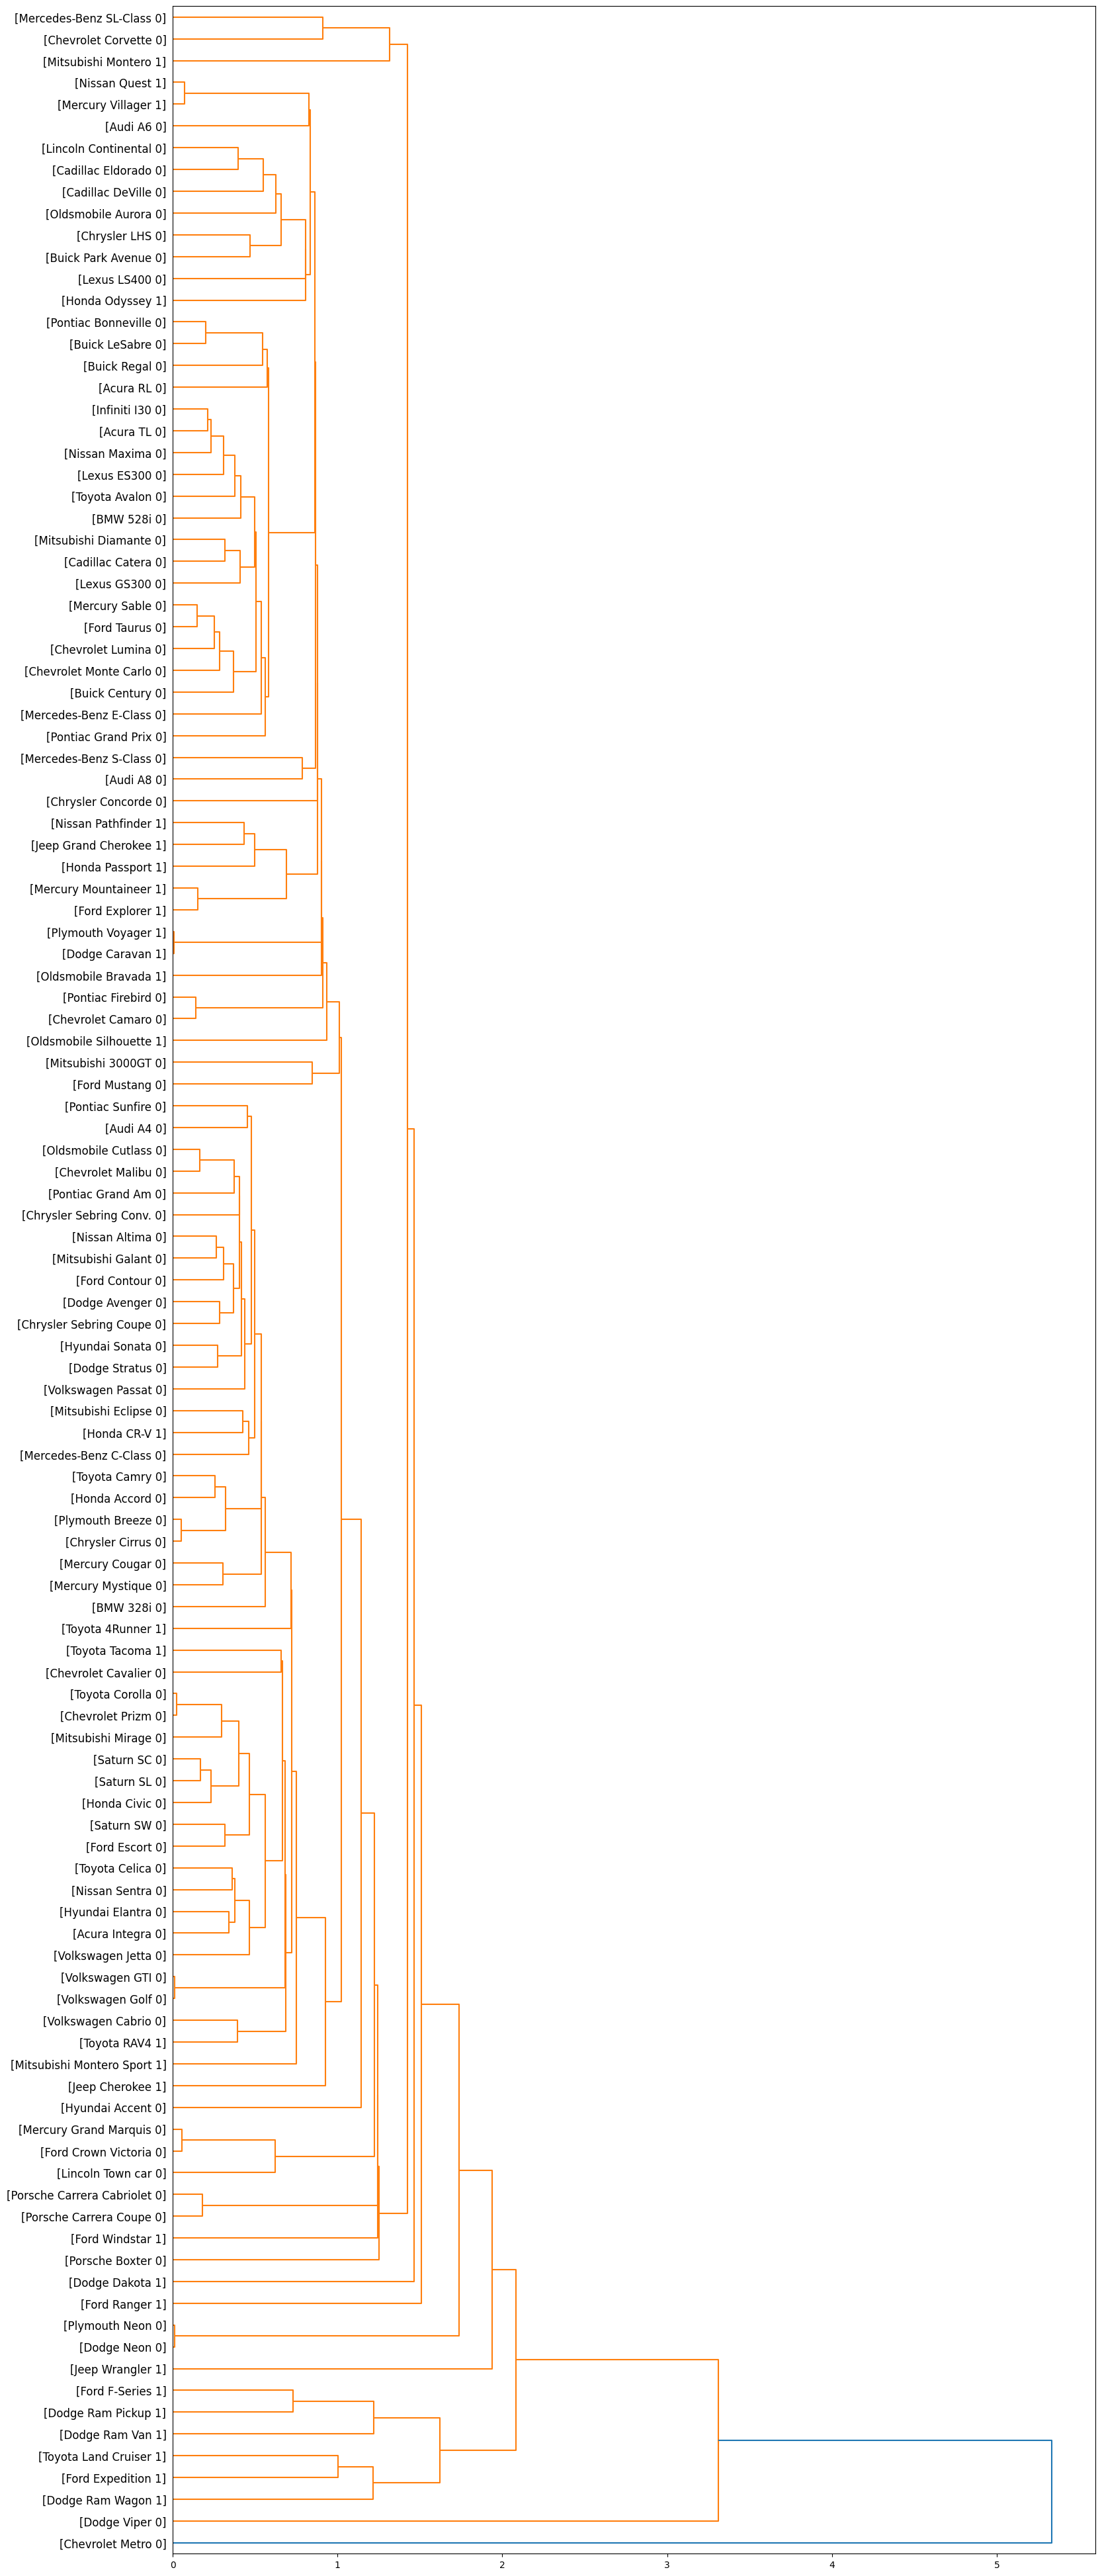

In [27]:
import matplotlib.pylab as pylab

fig = pylab.figure(figsize=(18,50))
def llf(id):
    return '[%s %s %s]' % (df['manufact'][id], df['model'][id], int(float(df['type'][id])) )

dendro = hierarchy.dendrogram(Z,  leaf_label_func=llf, leaf_rotation=0, leaf_font_size =12, orientation = 'right')

# def llf(id):: llf (leaf label function) nomli funksiya aniqlaydi. Bu funksiya dendrogrammadagi har bir barg
# (ma'lumot nuqtasi) uchun yorliq (label) yaratish uchun ishlatiladi. U id (indeks) ni qabul qiladi.

# return '[%s %s %s]' % (df['manufact'][id], df['model'][id], int(float(df['type'][id])) ): llf funksiyasi
# df (DataFrame) dan id indeksiga mos keluvchi avtomobilning ishlab chiqaruvchisi (manufact), modeli (model)
# va turi (type) ma'lumotlarini olib, ularni formatlangan satr ko'rinishida qaytaradi. int(float(df['type'][id]))
# qismi type ustunidagi qiymatni avval float, so'ngra butun songa o'tkazadi, ehtimol, u yerda kasrli sonlar mavjud bo'lgani uchun.

# dendro = hierarchy.dendrogram(Z, leaf_label_func=llf, leaf_rotation=0, leaf_font_size =12, orientation = 'right'):
# Bu asosiy buyruq bo'lib, Z (oldingi bosqichda yaratilgan bog'lanish matritsasi) asosida dendrogramma chizadi.
# Z: Ierarxik klasterlash natijasi bo'lgan bog'lanish matritsasi.
# leaf_label_func=llf: Dendrogrammadagi barglar uchun yorliq yaratishda yuqorida aniqlangan llf funksiyasidan foydalanishni belgilaydi.
# leaf_rotation=0: Barg yorliqlarining aylanish burchagini 0 daraja qilib belgilaydi (gorizontal joylashuv).
# leaf_font_size =12: Barg yorliqlarining shrift o'lchamini 12 qilib belgilaydi.
# orientation = 'right': Dendrogrammaning yo'nalishini belgilaydi, bu holda klasterlar o'ng tomonga tarqaladi.


Klasterlar sonini o'zimiz belgilab, dendogramni qayerdan kesishni ko'rsatishimiz mumkin.

In [28]:
from scipy.cluster.hierarchy import fcluster
# Bu funksiya ierarxik klasterlash natijasidan tekis klasterlar hosil qilish uchun ishlatiladi.
k = 5 # 5 ta klaster
clusters = fcluster(Z, k, criterion='maxclust')
clusters

# k = 5 # 5 ta klaster: Klasterlar sonini 5 ga teng qilib belgilaydi va k o'zgaruvchisiga saqlaydi.
# clusters = fcluster(Z, k, criterion='maxclust'): fcluster funksiyasini chaqirib, ierarxik klasterlash
# natijasi (Z bog'lanish matritsasi) va belgilangan k (5 ta klaster) asosida ma'lumotlarni klasterlarga
# ajratadi. criterion='maxclust' parametri aynan k ta klaster hosil qilishni kafolatlaydi.

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       5, 2, 2, 2, 2, 2, 2, 2, 2, 4, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2], dtype=int32)

## `scikit` yordamida klasterlash

In [29]:
from sklearn import manifold, datasets
from sklearn.cluster import AgglomerativeClustering

In [34]:
agglom = AgglomerativeClustering(n_clusters = 6, linkage = 'complete')
agglom.fit(D)

agglom.labels_

# agglom = AgglomerativeClustering(n_clusters = 6, linkage = 'complete'): AgglomerativeClustering
# modelini yaratadi. Bu model ierarxik klasterlashni amalga oshiradi.

# n_clusters = 6: Ma'lumotlarni 6 ta klasterga ajratishni belgilaydi.
# linkage = 'complete': Klasterlar orasidagi masofani hisoblash usulini (bog'lanish strategiyasini) complete
# linkage qilib belgilaydi. Bu usul ikki klasterdagi eng uzoq nuqtalar orasidagi masofani hisoblaydi.
# agglom.fit(D): Yaratilgan AgglomerativeClustering modelini D masofa matritsasi yordamida o'qitadi.
# Bu bosqichda klasterlash jarayoni amalga oshiriladi.

# agglom.labels_: Klasterlash natijasida har bir ma'lumot nuqtasi qaysi klasterga tegishli ekanligini ko'rsatuvchi
# yorliqlarni (labels) qaytaradi. Bu array klasterlashning yakuniy natijasi hisoblanadi.



/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:588: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  out = hierarchy.linkage(X, method=linkage, metric=affinity)


array([1, 2, 2, 3, 2, 4, 3, 2, 2, 2, 2, 2, 4, 4, 2, 1, 3, 2, 2, 2, 4, 1,
       5, 3, 3, 2, 3, 2, 1, 3, 3, 0, 0, 0, 0, 4, 2, 1, 3, 3, 2, 4, 2, 4,
       0, 3, 0, 1, 3, 3, 2, 4, 1, 1, 3, 2, 1, 3, 2, 2, 2, 4, 4, 4, 1, 3,
       3, 2, 3, 4, 3, 3, 3, 2, 4, 2, 2, 3, 2, 4, 4, 1, 3, 2, 2, 2, 3, 4,
       2, 4, 1, 3, 2, 3, 3, 2, 2, 2, 3, 3, 3, 1, 1, 1, 1, 3, 2, 1, 1, 1,
       3, 0, 1, 1, 3, 1, 1])

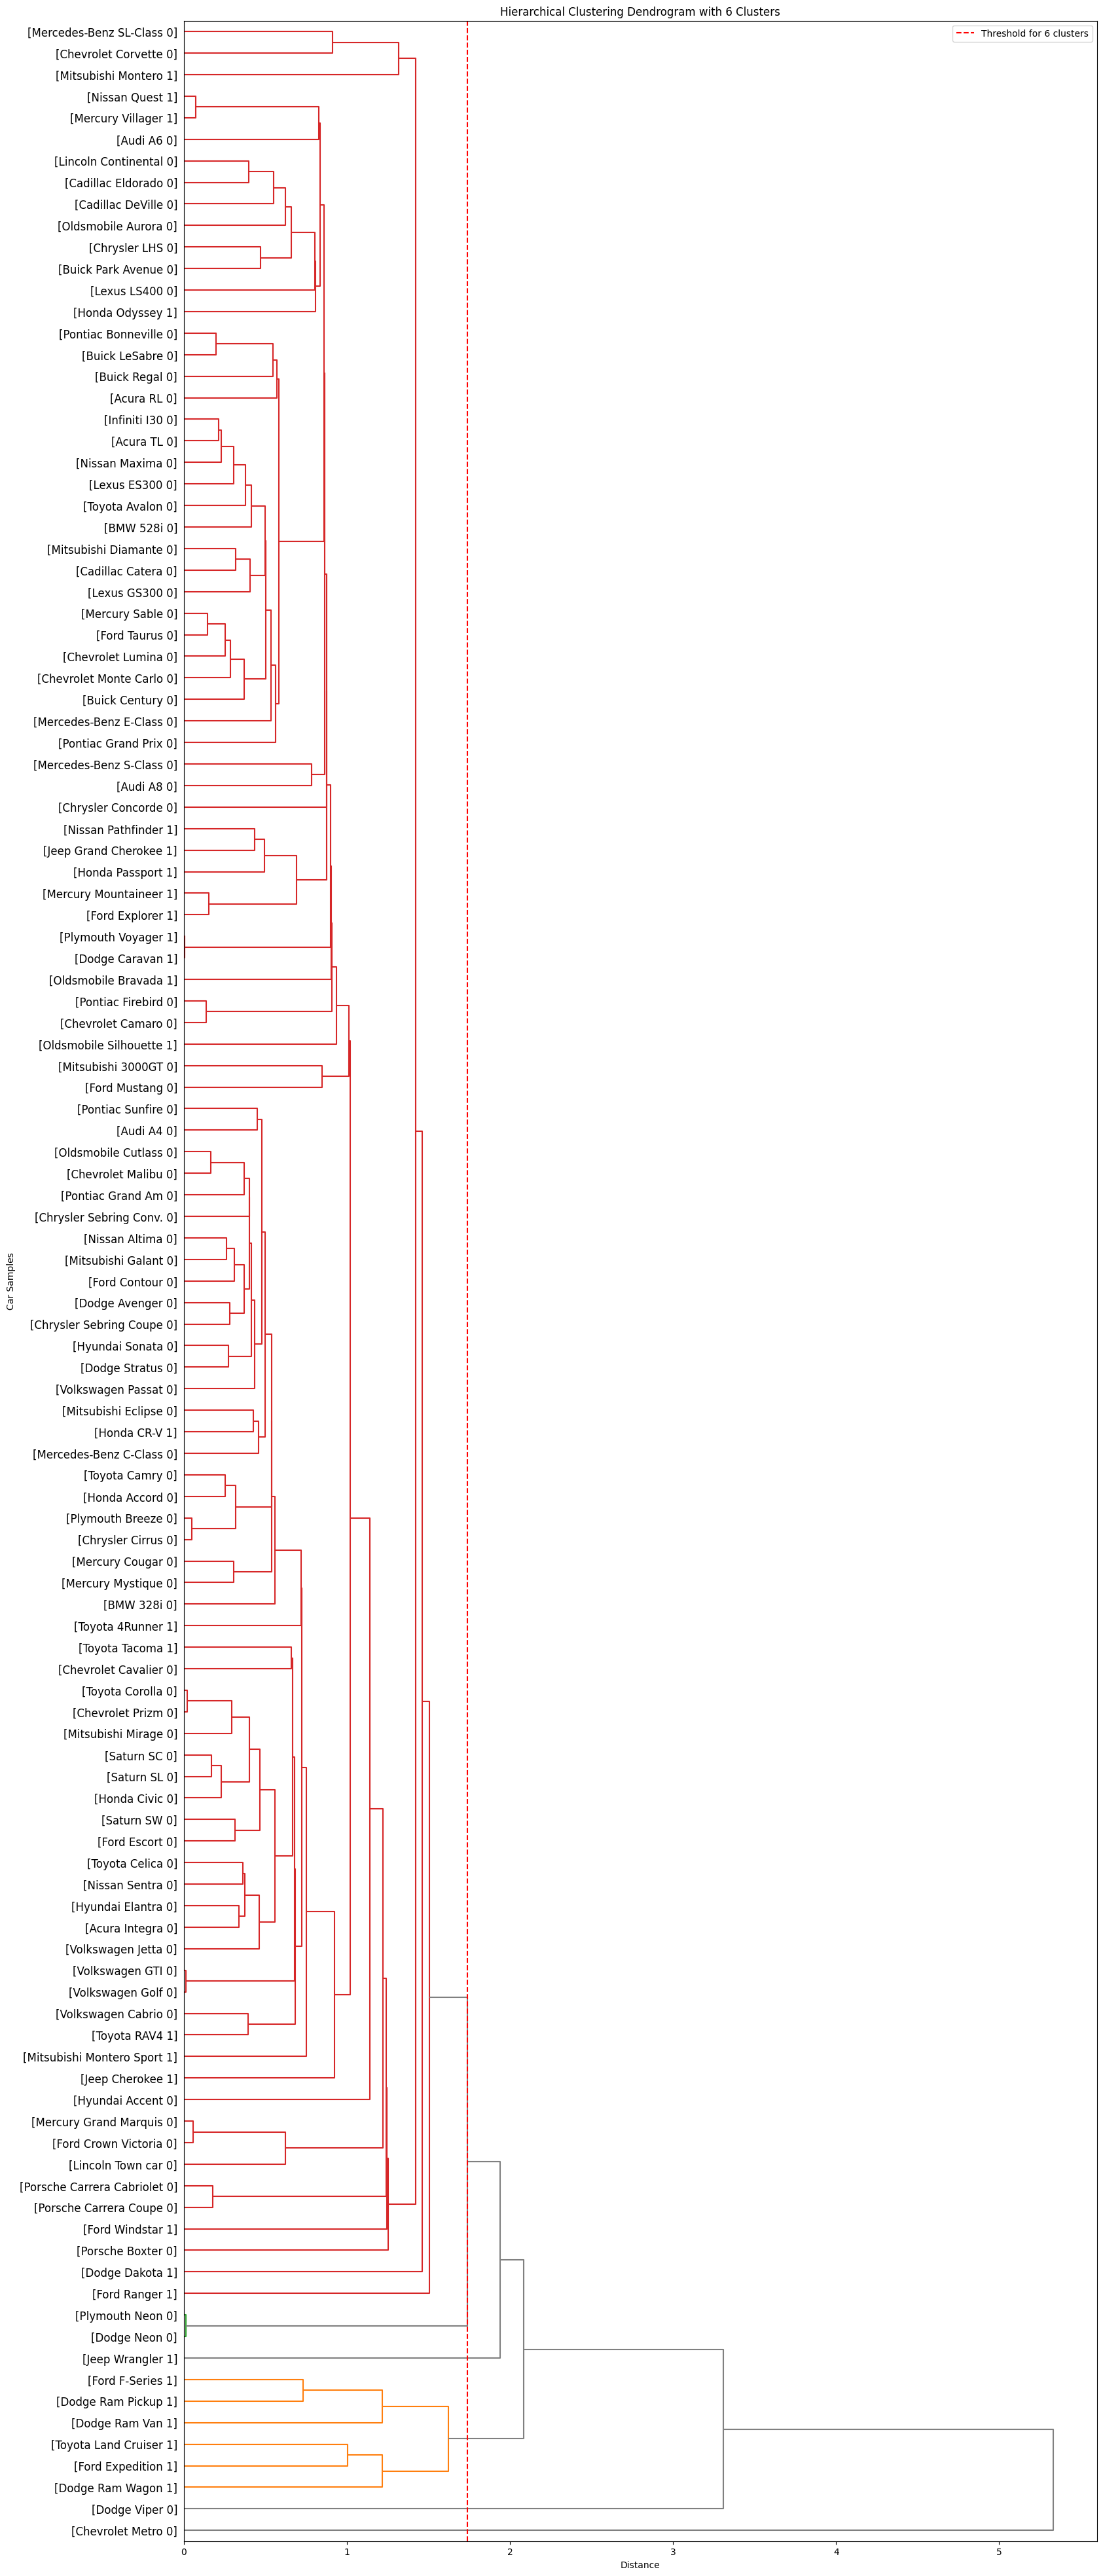

In [38]:
import matplotlib.pyplot as plt

k_clusters = 6

threshold_distance = Z[-(k_clusters - 1), 2]

fig = pylab.figure(figsize=(18, 50))
dendro = hierarchy.dendrogram(Z,
                              leaf_label_func=llf,
                              leaf_rotation=0,
                              leaf_font_size=12,
                              orientation='right',
                              color_threshold=threshold_distance, # Color links below this threshold differently
                              above_threshold_color='gray') # Color links above the threshold in gray

pylab.axvline(x=threshold_distance, color='r', linestyle='--', label=f'Threshold for {k_clusters} clusters')
pylab.title(f'Hierarchical Clustering Dendrogram with {k_clusters} Clusters')
pylab.xlabel('Distance')
pylab.ylabel('Car Samples')
pylab.legend()
pylab.show()

### Klasterlar haqida nima deya olamiz?

In [36]:
df['cluster'] = agglom.labels_
agg_cars = df.groupby(['cluster','type'])[['horsepow','engine_s','mpg','price']].mean()
agg_cars

# df['cluster'] = agglom.labels_: Avtomobillar DataFrame'iga (df) yangi cluster ustunini qo'shadi.
# Bu ustun har bir avtomobil qaysi klasterga tegishli ekanligini agglom.labels_ (AgglomerativeClustering
# tomonidan aniqlangan klaster yorliqlari) dan olgan qiymatlar bilan ko'rsatadi.

# agg_cars = df.groupby(['cluster','type'])[['horsepow','engine_s','mpg','price']].mean(): Ushbu qator bir nechta amallarni bajaradi:

# df.groupby(['cluster','type']): DataFrame'ni cluster va type ustunlari bo'yicha guruhlaydi.
# Bu har bir klasterdagi har xil turdagi avtomobillarni alohida ko'rib chiqish imkonini beradi.
# [['horsepow','engine_s','mpg','price']]: Guruhlangandan so'ng, faqat horsepow (ot kuchi), engine_s
# (dvigatel hajmi), mpg (yoqilg'i iste'moli) va price (narxi) ustunlarini tanlaydi.
# .mean(): Tanlangan ustunlar bo'yicha har bir guruh uchun o'rtacha qiymatni hisoblaydi.
# Natija agg_cars nomli yangi DataFrame'ga saqlanadi.

horsepow  engine_s        mpg      price
cluster type                                            
0       0.0   450.000000  8.000000  16.000000  69.725000
        1.0   211.666667  4.483333  16.166667  29.024667
1       0.0   118.500000  1.890000  29.550000  14.226100
        1.0   129.666667  2.300000  22.333333  14.292000
2       0.0   203.615385  3.284615  24.223077  27.988692
        1.0   182.000000  3.420000  20.300000  26.120600
3       0.0   168.107143  2.557143  25.107143  24.693786
        1.0   155.600000  2.840000  22.000000  19.807000
4       0.0   267.666667  4.566667  21.416667  46.417417
        1.0   173.000000  3.180000  20.600000  24.308400
5       0.0    55.000000  1.000000  45.000000   9.235000

**Klasterlar haqida xulosa qilishni sizga qoldiramiz.**

Bizning maqsadimiz avtomobillar datasetini (cars_clus.csv) o'xshash xususiyatlarga ko'ra guruhlash, ya'ni klasterlash edi. Buning uchun ierarxik klasterlash usulidan foydalanildi. Jarayon quyidagi asosiy bosqichlardan iborat bo'ldi:

Ma'lumotlarni yuklash va tozalash: Dastlab, avtomobillar ma'lumotlari CSV fayldan pandas DataFrame'ga yuklandi. Ma'lumotlarda bo'sh (NaN) qiymatlar mavjudligi sababli, ular pd.to_numeric yordamida raqamli turga o'tkazildi va dropna() yordamida tozalash ishlari olib borildi. Bu klasterlash algoritmlari to'g'ri ishlashi uchun juda muhim edi.

Xususiyatlarni tanlash va normalizatsiya: Klasterlash uchun avtomobilning dvigatel hajmi (engine_s), ot kuchi (horsepow), g'ildirak bazasi (wheelbas), kengligi (width), uzunligi (length), og'irligi (curb_wgt), yonilg'i sig'imi (fuel_cap) va yoqilg'i samaradorligi (mpg) kabi raqamli xususiyatlar tanlab olindi. Bu xususiyatlar MinMaxScaler yordamida 0 dan 1 gacha bo'lgan oraliqqa normalizatsiya qilindi. Normalizatsiya turli o'lchov birliklariga ega bo'lgan xususiyatlarning klasterlash jarayoniga teng ta'sir ko'rsatishini ta'minlaydi.

Masofa matritsasini hisoblash: scipy.spatial.distance.euclidean funksiyasi yordamida normalizatsiya qilingan ma'lumotlar nuqtalari orasidagi Euklid masofalari hisoblandi. Bu masofalar D nomli matritsada saqlandi, bu ierarxik klasterlashning asosini tashkil etadi.

Ierarxik klasterlash va dendrogramma: scipy.cluster.hierarchy.linkage(D) funksiyasi yordamida ierarxik klasterlash amalga oshirildi va Z bog'lanish matritsasi yaratildi. So'ngra, matplotlib.pylab va hierarchy.dendrogram yordamida dendrogramma vizuallashtirildi. Dendrogramma ma'lumotlar nuqtalari qanday ketma-ketlikda birlashib, klasterlarni hosil qilganini ko'rsatadi. Uning yordamida ma'lum bir masofa chegarasi (yoki klasterlar soni) asosida klasterlarni kesish mumkinligi aniq ko'rinadi.

Klasterlarni ajratish (fcluster va AgglomerativeClustering): Biz fcluster yordamida dendrogrammani 5 ta klasterga bo'ldik. Shuningdek, scikit-learn kutubxonasidan AgglomerativeClustering modelini ham qo'lladik va undan 6 ta klaster hosil qildik. Bu ikki usul ham ierarxik klasterlashning turlicha implementatsiyalaridir.

Yaratilgan klasterlar haqida xulosa:

AgglomerativeClustering tomonidan 6 ta klasterga ajratilgan ma'lumotlarimizni agg_cars DataFrame'i orqali tahlil qildik. Har bir klasterdagi avtomobillarning o'rtacha ot kuchi, dvigatel hajmi, yonilg'i samaradorligi va narxi bo'yicha tahlil natijalari shuni ko'rsatdiki:

Klaster 0: Odatda, juda yuqori ot kuchi, katta dvigatel, past yonilg'i samaradorligi va eng yuqori narxga ega bo'lgan avtomobillar (Hashamatli/Yuqori samarali).
Klaster 1: Past ot kuchi, kichik dvigatel, yuqori yonilg'i samaradorligi va eng arzon narxga ega bo'lgan avtomobillar (Iqtisodiy/Kichik).
Klaster 2 va 3: O'rtacha ot kuchi, dvigatel hajmi, yonilg'i samaradorligi va o'rtacha narxga ega bo'lgan avtomobillar (O'rta sinf/Oilaviy).
Klaster 4: Yuqori ot kuchi, katta dvigatel, ammo Klaster 0 ga qaraganda biroz pastroq narx va o'rtacha yonilg'i samaradorligiga ega bo'lgan avtomobillar (Yuqori darajadagi/SUV).
Klaster 5: Eng past ot kuchi, eng kichik dvigatel, eng yuqori yonilg'i samaradorligi va juda arzon narxga ega bo'lgan avtomobillar (Mikro/Juda tejamkor).
Umumiy xulosa:

Ierarxik klasterlash yordamida biz avtomobillar datasetini ularning texnik xususiyatlariga ko'ra aniq va ma'noli guruhlarga ajrata oldik. Bu klasterlash natijalari avtomobil ishlab chiqaruvchilariga marketing strategiyalarini ishlab chiqishda, iste'molchilarga avtomobil tanlashda yoki avtomobil bozorini tahlil qilishda foydali bo'lishi mumkin. Har bir klaster o'ziga xos xususiyatlarga ega bo'lgan avtomobillar segmentini ifodalaydi.

